
TP - Commande Optimale EDP Elliptique
======================================
Données du prof :
  f(x)    = 2 + (1/alpha)*sin(pi*x)
  z_d(x)  = x - x² - pi²*sin(pi*x)
 
Solution exacte :
  y*(x)   = x*(1-x)
  p*(x)   = sin(pi*x)
  u*(x)   = -(1/alpha)*p*(x) = -(1/alpha)*sin(pi*x)   [Cas 1]
 
On va :
  1. Résoudre numériquement pour plusieurs valeurs de alpha et N
  2. Comparer à la solution exacte
  3. Mesurer l'erreur


In [8]:
import numpy as np
from scipy.linalg import solve
import matplotlib.pyplot as plt

FONCTIONS UTILITAIRES

In [9]:
def construire_A(N):
    """Construit la matrice tridiagonale A de taille N×N."""
    h = 1.0 / (N + 1)
    A = (1.0/h**2) * (
          np.diag(2.0*np.ones(N))
        + np.diag(-1.0*np.ones(N-1),  1)
        + np.diag(-1.0*np.ones(N-1), -1))
    return A, h
 
def donnees_prof(x, alpha):
    """Retourne f et z_d selon les données du prof."""
    f   = 2.0 + (1.0/alpha) * np.sin(np.pi * x)
    z_d = x - x**2 - np.pi**2 * np.sin(np.pi * x)
    return f, z_d
 
def solution_exacte(x, alpha):
    """Retourne la solution exacte y*, p*, u*."""
    y_ex = x * (1 - x)
    p_ex = np.sin(np.pi * x)
    u_ex = -(1.0/alpha) * np.sin(np.pi * x)
    return y_ex, p_ex, u_ex
 
def resoudre_cas1(N, alpha):
    """Résout le Cas 1 (sans contrainte) et retourne Y, P, U, x."""
    A, h = construire_A(N)
    x    = np.linspace(h, 1-h, N)
    f, z_d = donnees_prof(x, alpha)
 
    M  = A @ A + (1.0/alpha) * np.eye(N)
    P  = solve(M, f - A @ z_d)
    Y  = A @ P + z_d
    U  = -(1.0/alpha) * P
    return Y, P, U, x, h
 
def resoudre_cas2(N, alpha):
    """Résout le Cas 2 (u >= 0) par itérations de point fixe."""
    A, h = construire_A(N)
    x    = np.linspace(h, 1-h, N)
    f, z_d = donnees_prof(x, alpha)
 
    # Initialisation depuis Cas 1
    Y1, P1, U1, _, _ = resoudre_cas1(N, alpha)
    P2 = P1.copy()
 
    for k in range(2000):
        P_old = P2.copy()
        U2    = -(1.0/alpha) * np.minimum(0.0, P2)
        Y2    = solve(A, f + U2)
        P2    = solve(A, Y2 - z_d)
        if np.linalg.norm(P2 - P_old) < 1e-10:
            break
 
    U2 = -(1.0/alpha) * np.minimum(0.0, P2)
    return Y2, P2, U2, x, h
 
def erreur_L2(num, ex, h):
    """Calcule l'erreur L² : ||num - ex||_L2 ≈ sqrt(h * sum((num-ex)²))"""
    return np.sqrt(h * np.sum((num - ex)**2))
 
def ajouter_bords(v):
    return np.concatenate([[0.0], v, [0.0]])
 

 VALIDATION : Comparaison numérique vs solution exacte

SECTION 1 — Validation avec la solution exacte
N=99, alpha=1.0
  Erreur L² sur y* : 5.83e-06
  Erreur L² sur p* : 5.76e-05
  Erreur L² sur u* : 5.76e-05


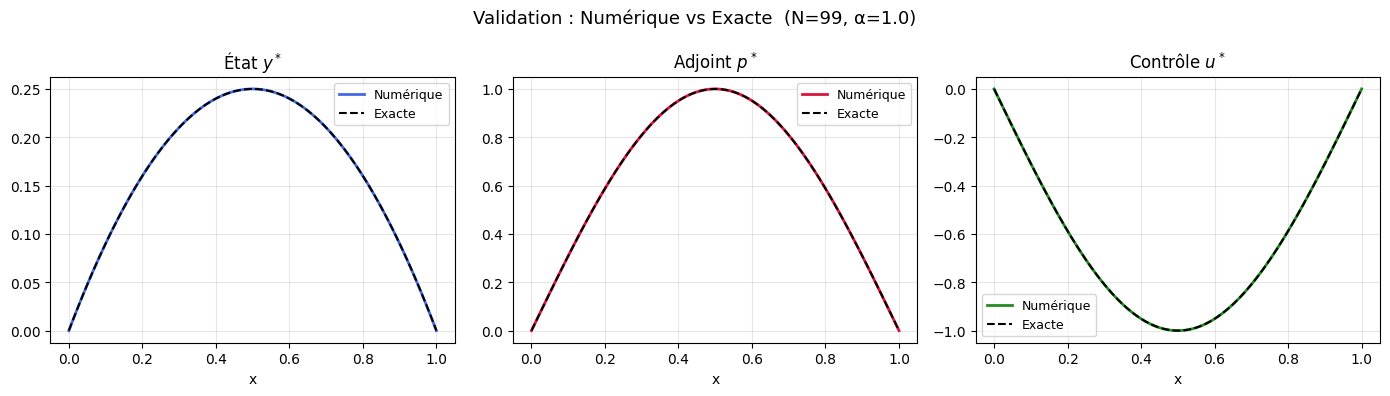

→ fig1_validation.png sauvegardée



In [10]:
print("=" * 60)
print("SECTION 1 — Validation avec la solution exacte")
print("=" * 60)
 
alpha_ref = 1.0
N_ref     = 99
 
Y1, P1, U1, x1, h1 = resoudre_cas1(N_ref, alpha_ref)
y_ex, p_ex, u_ex   = solution_exacte(x1, alpha_ref)
 
err_y = erreur_L2(Y1, y_ex, h1)
err_p = erreur_L2(P1, p_ex, h1)
err_u = erreur_L2(U1, u_ex, h1)
 
print(f"N={N_ref}, alpha={alpha_ref}")
print(f"  Erreur L² sur y* : {err_y:.2e}")
print(f"  Erreur L² sur p* : {err_p:.2e}")
print(f"  Erreur L² sur u* : {err_u:.2e}")
 
# Graphique de comparaison numérique vs exacte
x_plot = np.concatenate([[0], x1, [1]])
 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f"Validation : Numérique vs Exacte  (N={N_ref}, α={alpha_ref})",
             fontsize=13)
 
labels_num = [Y1, P1, U1]
labels_ex  = [y_ex, p_ex, u_ex]
titres     = ["État $y^*$", "Adjoint $p^*$", "Contrôle $u^*$"]
couleurs   = ['royalblue', 'crimson', 'forestgreen']
 
for j in range(3):
    ax = axes[j]
    ax.plot(x_plot, ajouter_bords(labels_num[j]),
            color=couleurs[j], linewidth=2, label='Numérique')
    ax.plot(x_plot, ajouter_bords(labels_ex[j]),
            color='black', linewidth=1.5, linestyle='--', label='Exacte')
    ax.set_title(titres[j])
    ax.set_xlabel("x")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("fig1_validation.png", dpi=150, bbox_inches='tight')
plt.show()
print("→ fig1_validation.png sauvegardée\n")
 
 

 ÉTUDE EN N : Convergence en fonction du pas h

SECTION 2 — Convergence en N (ordre de la méthode)
  N=  9  h=0.1000  |  err_y=5.91e-04  err_p=5.78e-03  err_u=5.78e-03
  N= 19  h=0.0500  |  err_y=1.46e-04  err_p=1.44e-03  err_u=1.44e-03
  N= 39  h=0.0250  |  err_y=3.65e-05  err_p=3.60e-04  err_u=3.60e-04
  N= 79  h=0.0125  |  err_y=9.12e-06  err_p=9.00e-05  err_u=9.00e-05
  N=159  h=0.0063  |  err_y=2.31e-06  err_p=2.25e-05  err_u=2.25e-05


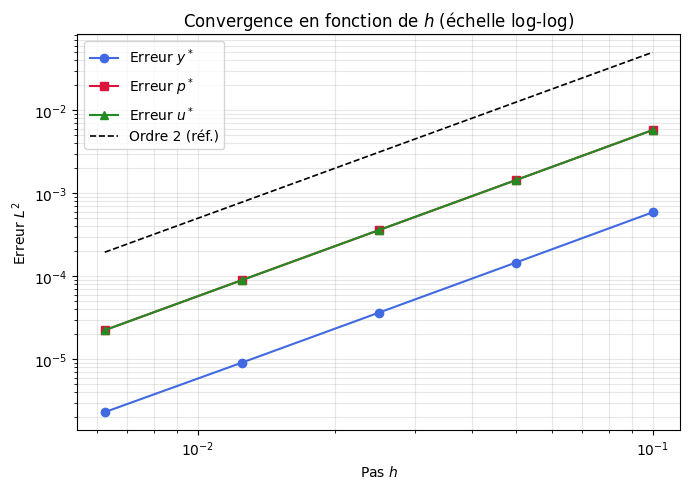

→ fig2_convergence_N.png sauvegardée



In [11]:
print("=" * 60)
print("SECTION 2 — Convergence en N (ordre de la méthode)")
print("=" * 60)
 
alpha_ref = 1.0
liste_N   = [9, 19, 39, 79, 159]
 
err_y_list, err_p_list, err_u_list, h_list = [], [], [], []
 
for N in liste_N:
    Y, P, U, x, h = resoudre_cas1(N, alpha_ref)
    y_ex, p_ex, u_ex = solution_exacte(x, alpha_ref)
    err_y_list.append(erreur_L2(Y, y_ex, h))
    err_p_list.append(erreur_L2(P, p_ex, h))
    err_u_list.append(erreur_L2(U, u_ex, h))
    h_list.append(h)
    print(f"  N={N:3d}  h={h:.4f}  |  "
          f"err_y={err_y_list[-1]:.2e}  "
          f"err_p={err_p_list[-1]:.2e}  "
          f"err_u={err_u_list[-1]:.2e}")
 
# Graphique de convergence en échelle log-log
h_arr = np.array(h_list)
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(h_arr, err_y_list, 'o-', color='royalblue',  label="Erreur $y^*$")
ax.loglog(h_arr, err_p_list, 's-', color='crimson',    label="Erreur $p^*$")
ax.loglog(h_arr, err_u_list, '^-', color='forestgreen', label="Erreur $u^*$")
 
# Droite de référence d'ordre 2
h_ref = np.array([h_arr.min(), h_arr.max()])
ax.loglog(h_ref, 5*h_ref**2, 'k--', linewidth=1.2, label="Ordre 2 (réf.)")
 
ax.set_xlabel("Pas $h$")
ax.set_ylabel("Erreur $L^2$")
ax.set_title("Convergence en fonction de $h$ (échelle log-log)")
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig("fig2_convergence_N.png", dpi=150, bbox_inches='tight')
plt.show()
print("→ fig2_convergence_N.png sauvegardée\n")
 

ÉTUDE EN alpha : Effet du paramètre de régularisation

SECTION 3 — Effet du paramètre alpha


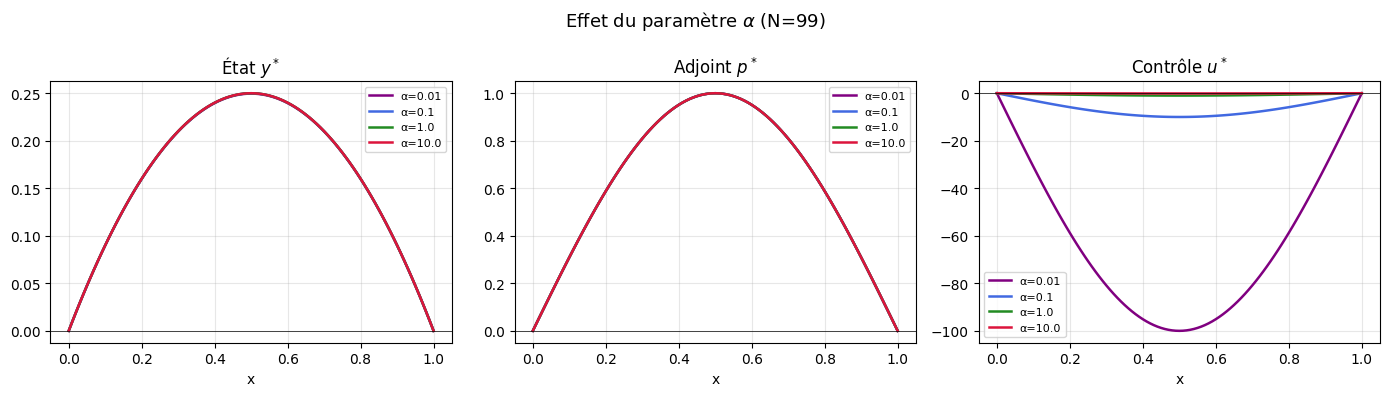

Valeurs de u* max selon alpha :
  alpha= 0.01 :  u* max=-3.1412  u* min=-100.0041
  alpha= 0.10 :  u* max=-0.3141  u* min=-10.0007
  alpha= 1.00 :  u* max=-0.0314  u* min=-1.0001
  alpha=10.00 :  u* max=-0.0031  u* min=-0.1000
→ fig3_effet_alpha.png sauvegardée



In [12]:
print("=" * 60)
print("SECTION 3 — Effet du paramètre alpha")
print("=" * 60)
 
N_ref      = 99
liste_alpha = [0.01, 0.1, 1.0, 10.0]
couleurs_a  = ['purple', 'royalblue', 'forestgreen', 'crimson']
 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f"Effet du paramètre $\\alpha$ (N={N_ref})", fontsize=13)
 
for alpha, couleur in zip(liste_alpha, couleurs_a):
    Y, P, U, x, h = resoudre_cas1(N_ref, alpha)
    x_plot = np.concatenate([[0], x, [1]])
    label  = f"α={alpha}"
 
    axes[0].plot(x_plot, ajouter_bords(Y), color=couleur,
                 linewidth=1.8, label=label)
    axes[1].plot(x_plot, ajouter_bords(P), color=couleur,
                 linewidth=1.8, label=label)
    axes[2].plot(x_plot, ajouter_bords(U), color=couleur,
                 linewidth=1.8, label=label)
 
titres = ["État $y^*$", "Adjoint $p^*$", "Contrôle $u^*$"]
for j, ax in enumerate(axes):
    ax.set_title(titres[j])
    ax.set_xlabel("x")
    ax.axhline(0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
 
plt.tight_layout()
plt.savefig("fig3_effet_alpha.png", dpi=150, bbox_inches='tight')
plt.show()
 
print("Valeurs de u* max selon alpha :")
for alpha in liste_alpha:
    Y, P, U, x, h = resoudre_cas1(N_ref, alpha)
    print(f"  alpha={alpha:5.2f} :  u* max={U.max():.4f}  u* min={U.min():.4f}")
print("→ fig3_effet_alpha.png sauvegardée\n")
 
 

 CAS 1 vs CAS 2 avec les données du prof

SECTION 4 — Cas 1 vs Cas 2 avec les données du prof
J(u*) Cas 1 = 49.204546
J(u*) Cas 2 = 49.709762
J_cas2 >= J_cas1 : True


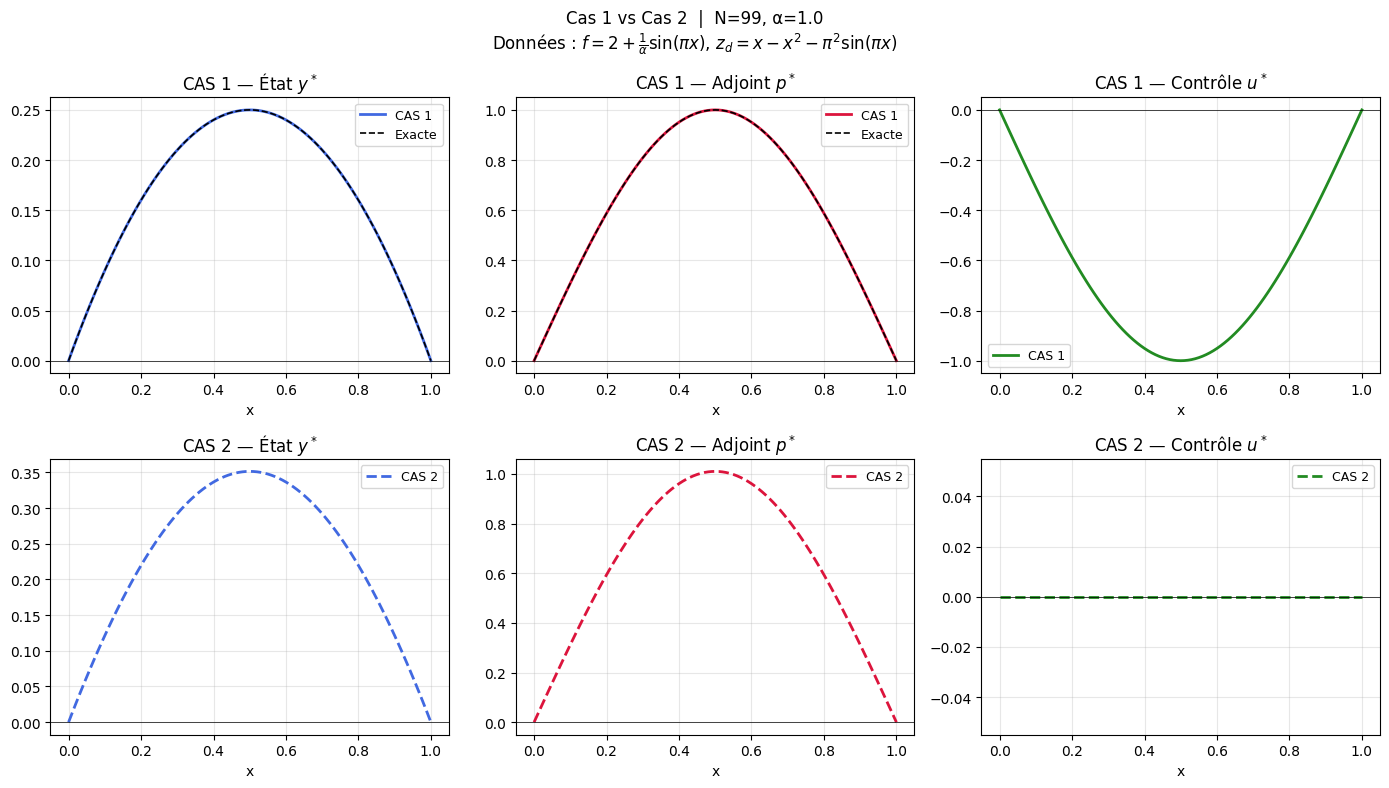

→ fig4_cas1_vs_cas2.png sauvegardée



In [13]:
print("=" * 60)
print("SECTION 4 — Cas 1 vs Cas 2 avec les données du prof")
print("=" * 60)
 
alpha_ref = 1.0
N_ref     = 99
 
Y1, P1, U1, x1, h1 = resoudre_cas1(N_ref, alpha_ref)
Y2, P2, U2, x2, h2 = resoudre_cas2(N_ref, alpha_ref)
y_ex, p_ex, u_ex   = solution_exacte(x1, alpha_ref)
 
J1 = h1*(np.sum((Y1 - (x1-x1**2-np.pi**2*np.sin(np.pi*x1)))**2)
         + alpha_ref*np.sum(U1**2))
J2 = h2*(np.sum((Y2 - (x2-x2**2-np.pi**2*np.sin(np.pi*x2)))**2)
         + alpha_ref*np.sum(U2**2))
 
print(f"J(u*) Cas 1 = {J1:.6f}")
print(f"J(u*) Cas 2 = {J2:.6f}")
print(f"J_cas2 >= J_cas1 : {J2 >= J1 - 1e-10}")
 
x_plot = np.concatenate([[0], x1, [1]])
 
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle(
    f"Cas 1 vs Cas 2  |  N={N_ref}, α={alpha_ref}\n"
    f"Données : $f=2+\\frac{{1}}{{\\alpha}}\\sin(\\pi x)$, "
    f"$z_d = x-x^2-\\pi^2\\sin(\\pi x)$",
    fontsize=12)
 
donnees = [
    ("CAS 1", Y1, P1, U1, '-'),
    ("CAS 2", Y2, P2, U2, '--'),
]
couleurs = ['royalblue', 'crimson', 'forestgreen']
titres   = ["État $y^*$", "Adjoint $p^*$", "Contrôle $u^*$"]
 
for i, (label, Y, P, U, ls) in enumerate(donnees):
    for j, (data, titre, coul) in enumerate(zip([Y,P,U], titres, couleurs)):
        ax = axes[i, j]
        ax.plot(x_plot, ajouter_bords(data),
                color=coul, linewidth=2, linestyle=ls, label=label)
        # Ajouter la solution exacte sur y et p
        if i == 0 and j == 0:
            ax.plot(x_plot, ajouter_bords(y_ex), 'k--',
                    linewidth=1.2, label='Exacte')
        if i == 0 and j == 1:
            ax.plot(x_plot, ajouter_bords(p_ex), 'k--',
                    linewidth=1.2, label='Exacte')
        ax.set_title(f"{label} — {titre}")
        ax.set_xlabel("x")
        ax.axhline(0, color='black', linewidth=0.5)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("fig4_cas1_vs_cas2.png", dpi=150, bbox_inches='tight')
plt.show()
print("→ fig4_cas1_vs_cas2.png sauvegardée\n")

RÉSUMÉ FINAL

In [14]:
print("=" * 60)
print("RÉSUMÉ FINAL")
print("=" * 60)
print(f"\nValidation (N={N_ref}, α={alpha_ref}) :")
print(f"  Erreur L² sur y* : {err_y:.2e}  (doit être ~ h² = {h1**2:.2e})")
print(f"  Erreur L² sur p* : {err_p:.2e}")
print(f"  Erreur L² sur u* : {err_u:.2e}")
print(f"\nConclusion convergence : méthode d'ordre 2 en h ✓")
print(f"\nCas 1 : J(u*) = {J1:.6f}")
print(f"Cas 2 : J(u*) = {J2:.6f}")
print(f"Contrainte u>=0 coûte : +{(J2-J1)/J1*100:.3f}%")
 

RÉSUMÉ FINAL

Validation (N=99, α=1.0) :
  Erreur L² sur y* : 5.83e-06  (doit être ~ h² = 1.00e-04)
  Erreur L² sur p* : 5.76e-05
  Erreur L² sur u* : 5.76e-05

Conclusion convergence : méthode d'ordre 2 en h ✓

Cas 1 : J(u*) = 49.204546
Cas 2 : J(u*) = 49.709762
Contrainte u>=0 coûte : +1.027%
